# KNN for All Failure Labels

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
DATA_PATH = Path("data/ai4i2020.csv")
TARGET_COLUMNS = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
DROP_COLUMNS = ["UID", "Product ID"]
MODEL_OPTIONS = {"knn_3": 3, "knn_5": 5, "knn_7": 7, "knn_9": 9}
RANDOM_STATE = 42
TEST_SIZE = 0.2

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=DROP_COLUMNS + TARGET_COLUMNS)
y = df[TARGET_COLUMNS]

cat_features = X.select_dtypes(include=["object"]).columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y["Machine failure"])

print(f"Dataset: {df.shape}, Train: {X_train.shape}, Test: {X_test.shape}")


Dataset: (10000, 14), Train: (8000, 6), Test: (2000, 6)


In [3]:
def create_model(n_neighbors):
    preprocessor = ColumnTransformer([("num", StandardScaler(), num_features), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)])
    clf = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=n_neighbors))
    return Pipeline([("preprocessor", preprocessor), ("classifier", clf)])


In [4]:
model_metrics = []
model_predictions = {}

for model_name, n_neighbors in MODEL_OPTIONS.items():
    model = create_model(n_neighbors)
    model.fit(X_train, y_train)
    pred_df = pd.DataFrame(model.predict(X_test), columns=TARGET_COLUMNS, index=y_test.index)
    model_predictions[model_name] = pred_df

    for target in TARGET_COLUMNS:
        model_metrics.append({
            "model": model_name, "target": target,
            "precision": precision_score(y_test[target], pred_df[target], zero_division=0),
            "recall": recall_score(y_test[target], pred_df[target], zero_division=0),
            "f1": f1_score(y_test[target], pred_df[target], zero_division=0)
        })

metrics_df = pd.DataFrame(model_metrics)
metrics_df


,model,target,precision,recall,f1
0,knn_3,Machine failure,0.677419,0.308824,0.424242
1,knn_3,TWF,0.333333,0.100000,0.153846
2,knn_3,HDF,0.500000,0.137931,0.216216
3,knn_3,PWF,0.750000,0.461538,0.571429
4,knn_3,OSF,0.727273,0.500000,0.592593
5,knn_3,RNF,0.000000,0.000000,0.000000
6,knn_5,Machine failure,0.833333,0.294118,0.434783
7,knn_5,TWF,0.000000,0.000000,0.000000
8,knn_5,HDF,0.750000,0.103448,0.181818
9,knn_5,PWF,0.833333,0.384615,0.526316


In [5]:
model_summary = metrics_df.groupby("model")[["precision", "recall", "f1"]].mean().sort_values("f1", ascending=False)
model_summary


,precision,recall,f1
model,,,
knn_3,0.498004,0.251382,0.326388
knn_5,0.539141,0.224114,0.301597
knn_7,0.523810,0.190180,0.273041
knn_9,0.620513,0.148941,0.225477


In [6]:
best_model = model_summary.index[0]
best_predictions = model_predictions[best_model]

print(f"Best model: {best_model}")
best_predictions.head()


Best model: knn_3


,Machine failure,TWF,HDF,PWF,OSF,RNF
2997,0,0,0,0,0,0
4871,0,0,0,0,0,0
3858,0,0,0,0,0,0
951,0,0,0,0,0,0
6463,0,0,0,0,0,0


In [7]:
metrics_df[metrics_df["model"] == best_model].drop("model", axis=1).reset_index(drop=True)


,target,precision,recall,f1
0,Machine failure,0.677419,0.308824,0.424242
1,TWF,0.333333,0.100000,0.153846
2,HDF,0.500000,0.137931,0.216216
3,PWF,0.750000,0.461538,0.571429
4,OSF,0.727273,0.500000,0.592593
5,RNF,0.000000,0.000000,0.000000


In [8]:
print(f"Classification reports for {best_model}:\n")
for target in TARGET_COLUMNS:
    y_true = y_test[target]
    y_pred = model_predictions[best_model][target]
    print(f"{target}:\n{classification_report(y_true, y_pred, zero_division=0)}")


Classification reports for knn_3:

Machine failure:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.68      0.31      0.42        68

    accuracy                           0.97      2000
   macro avg       0.83      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000

TWF:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1990
           1       0.33      0.10      0.15        10

    accuracy                           0.99      2000
   macro avg       0.66      0.55      0.58      2000
weighted avg       0.99      0.99      0.99      2000

HDF:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1971
           1       0.50      0.14      0.22        29

    accuracy                           0.99      2000
   macro avg       0.74      0.57      0.60      2000
weighted avg

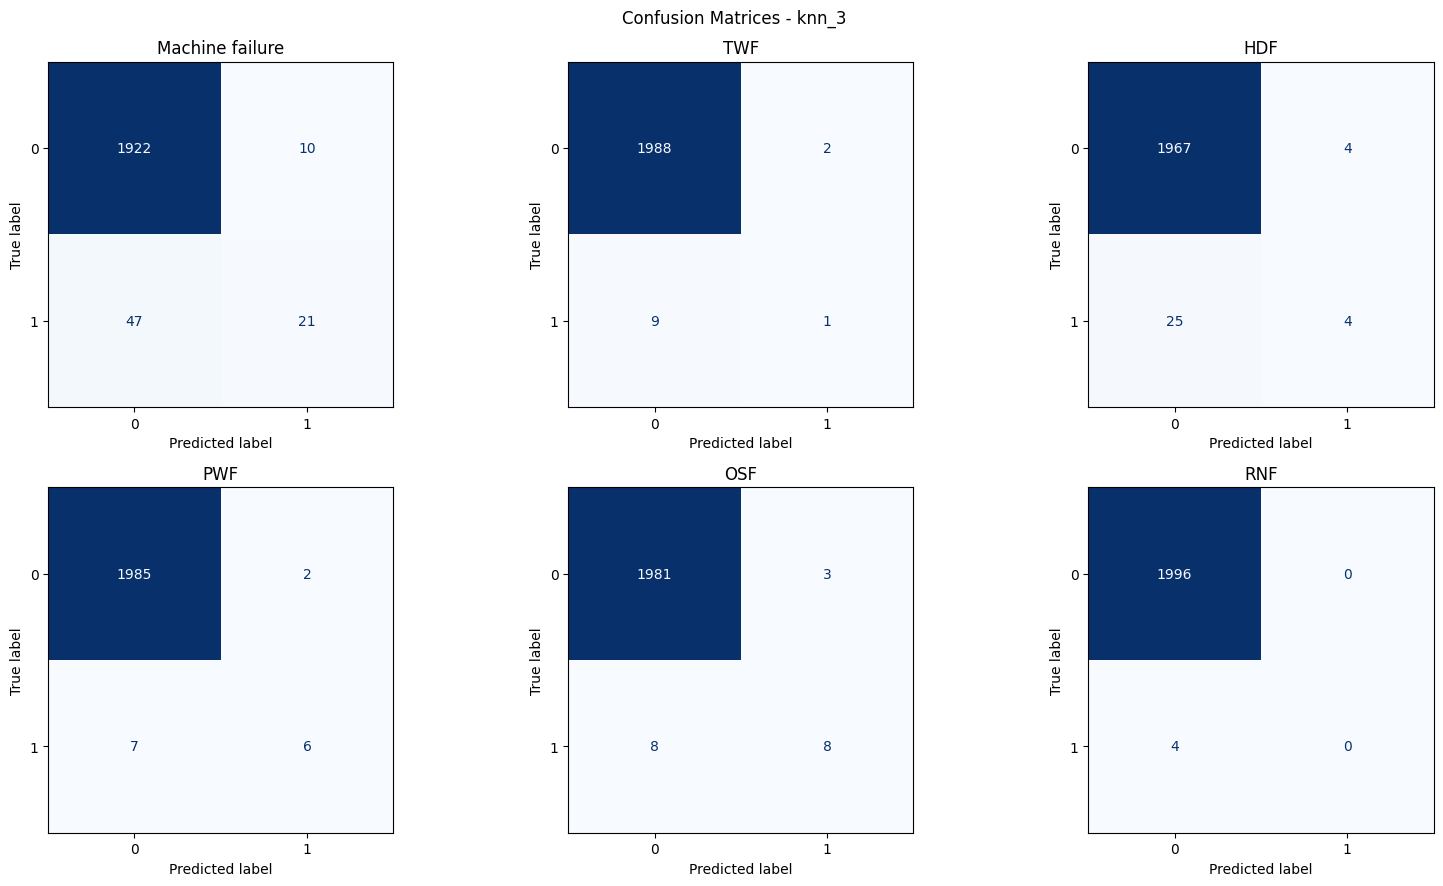

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, target in enumerate(TARGET_COLUMNS):
    y_true = y_test[target]
    y_pred = model_predictions[best_model][target]
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=[0, 1], cmap="Blues", colorbar=False, ax=axes.flat[i])
    axes.flat[i].set_title(target)
plt.suptitle(f"Confusion Matrices - {best_model}")
plt.tight_layout()
plt.show()
